# New approach to synthetic data generation


*   Before: ulcer mask -> realistic image
*   Now: (cornea region + ulcer region + ulcer boundary) -> realistic image



In [1]:
import os, numpy as np, cv2, random
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

BASE="/content/drive/MyDrive/Corneal_ulcer_model"

train_images = np.load(os.path.join(BASE, "train_images.npy")).astype(np.float32)
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy")).astype(np.uint8)
train_cornea = np.load(os.path.join(BASE, "train_cornea.npy")).astype(np.uint8)

def ensure_1ch(m):
  if m.ndim == 3:
    return np.expand_dims(m, -1)
  return m

train_ulcer = ensure_1ch(train_ulcer)
train_cornea= ensure_1ch(train_cornea)

train_ulcer = (train_ulcer  > 0).astype(np.float32)
train_cornea= (train_cornea > 0).astype(np.float32)

print("train_images:", train_images.shape, train_images.min(), train_images.max())
print("train_ulcer:", train_ulcer.shape, np.unique(train_ulcer))
print("train_cornea:", train_cornea.shape, np.unique(train_cornea))


Mounted at /content/drive
train_images: (247, 256, 256, 3) 0.0 1.0
train_ulcer: (247, 256, 256, 1) [0. 1.]
train_cornea: (247, 256, 256, 1) [0. 1.]


In [2]:
#Conditioning : Cornea + ulcer + ulcer edges
def mask_edges(binary_1ch):
  m= binary_1ch.squeeze().astype(np.uint8)  #(H,W)in {0,1}
  e= cv2.Canny(m * 255, 50, 150)
  e= (e > 0).astype(np.float32)
  return e[..., None]  #(H,W,1)

def make_cond(cornea_1ch, ulcer_1ch):
  # inputs are (H,W,1) in {0,1}
  e = mask_edges(ulcer_1ch.astype(np.uint8))
  x = np.concatenate([cornea_1ch, ulcer_1ch, e], axis=-1).astype(np.float32)  #(H,W,3) in [0,1]
  return x

In [3]:
#Build training pairs
X_cond =[]
for i in range(len(train_ulcer)):
  X_cond.append(make_cond(train_cornea[i], train_ulcer[i]))

X_cond = np.stack(X_cond, axis=0).astype(np.float32)   #(N,H,W,3) in [0,1]
Y_img  = train_images.astype(np.float32)               #(N,H,W,3) in [0,1]

#normalising to [-1,1] for pix2pix
X_cond_n= X_cond * 2.0 - 1.0
Y_img_n= Y_img  * 2.0 - 1.0

print("X_cond:", X_cond.shape, X_cond.min(), X_cond.max())
print("Y_img :", Y_img.shape,  Y_img.min(),  Y_img.max())


X_cond: (247, 256, 256, 3) 0.0 1.0
Y_img : (247, 256, 256, 3) 0.0 1.0


In [4]:

!pip -q install git+https://github.com/tensorflow/examples.git
from tensorflow_examples.models.pix2pix import pix2pix

  Preparing metadata (setup.py) ... done


In [5]:
#Train pix2pix version 2
BATCH = 8
ds= tf.data.Dataset.from_tensor_slices((X_cond_n, Y_img_n))
ds= ds.shuffle(1000, reshuffle_each_iteration=True).batch(BATCH).prefetch(tf.data.AUTOTUNE)

generatorV2 = pix2pix.unet_generator(output_channels=3, norm_type='batchnorm')
discriminatorV2 =pix2pix.discriminator(norm_type='batchnorm', target=True)

loss_object= tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real, fake):
  return loss_object(tf.ones_like(real), real) + loss_object(tf.zeros_like(fake),fake)

def g_loss(fake_disc, target, gen_out, L1_WEIGHT=100.0):
    l1 = tf.reduce_mean(tf.abs(target - gen_out))
    gan = loss_object(tf.ones_like(fake_disc), fake_disc)
    return gan + L1_WEIGHT * l1

g_optimiser= tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
d_optimiser = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def trainStep(inp, tar, L1_WEIGHT=100.0):
  with tf.GradientTape() as gt,tf.GradientTape() as dt:
      gen_out= generatorV2(inp, training=True)
      disc_real= discriminatorV2([inp, tar], training=True)
      disc_fake= discriminatorV2([inp, gen_out], training=True)

      gloss  = g_loss(disc_fake, tar, gen_out, L1_WEIGHT=L1_WEIGHT)
      dloss = d_loss(disc_real, disc_fake)

  g_optimiser.apply_gradients(zip(gt.gradient(gloss, generatorV2.trainable_variables),
                              generatorV2.trainable_variables))
  d_optimiser.apply_gradients(zip(dt.gradient(dloss, discriminatorV2.trainable_variables),
                              discriminatorV2.trainable_variables))
  return gloss, dloss

EPOCHS = 50
for epoch in range(EPOCHS):
    last_gl,last_dl = None, None
    for inp,tar in ds:
        last_gl,last_dl= trainStep(inp, tar, L1_WEIGHT=100.0)
    print(f"Epoch {epoch+1}/{EPOCHS} | G {float(last_gl):.3f} | D {float(last_dl):.3f}")

# Save model
model_dir = os.path.join(BASE, "models")
os.makedirs(model_dir, exist_ok=True)
gen_path = os.path.join(model_dir, "pix2pix_generator_V2.keras")
generatorV2.save(gen_path)
print("Saved generator v2 to:", gen_path)

Epoch 1/50 | G 33.593 | D 0.767
Epoch 2/50 | G 27.671 | D 0.713
Epoch 3/50 | G 26.308 | D 0.529
Epoch 4/50 | G 24.672 | D 0.886
Epoch 5/50 | G 30.084 | D 0.417
Epoch 6/50 | G 25.164 | D 0.481
Epoch 7/50 | G 23.026 | D 0.481
Epoch 8/50 | G 25.610 | D 0.798
Epoch 9/50 | G 23.263 | D 0.714
Epoch 10/50 | G 23.898 | D 0.722
Epoch 11/50 | G 23.071 | D 0.863
Epoch 12/50 | G 23.115 | D 0.739
Epoch 13/50 | G 21.945 | D 0.693
Epoch 14/50 | G 22.261 | D 0.632
Epoch 15/50 | G 20.359 | D 0.798
Epoch 16/50 | G 20.595 | D 0.731
Epoch 17/50 | G 22.211 | D 0.800
Epoch 18/50 | G 19.654 | D 0.871
Epoch 19/50 | G 20.122 | D 0.808
Epoch 20/50 | G 21.774 | D 1.498
Epoch 21/50 | G 19.363 | D 0.984
Epoch 22/50 | G 18.236 | D 1.013
Epoch 23/50 | G 18.918 | D 0.849
Epoch 24/50 | G 16.622 | D 0.818
Epoch 25/50 | G 16.951 | D 0.963
Epoch 26/50 | G 17.379 | D 0.796
Epoch 27/50 | G 16.691 | D 1.373
Epoch 28/50 | G 15.210 | D 1.031
Epoch 29/50 | G 18.724 | D 1.091
Epoch 30/50 | G 16.228 | D 0.857
Epoch 31/50 | G 15.

In [16]:
#Prepare v2 perturbed conditioning masks(ulcer + replicated cornea)
#Used existing perturbed_masksV2.npy created earlier
#cleanign the perturbed masks

def clean_binary_mask(mask01, border=2):
    m = mask01.squeeze()
    m = (m > 0).astype(np.uint8)
    k = np.ones((3,3), np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=1)
    b = int(border)
    if b > 0:
      m[:b, :] = 0
      m[-b:, :] = 0
      m[:, :b] = 0
      m[:, -b:] = 0

    return m[..., None]

PERT_PATH = os.path.join(BASE, "perturbed_masks.npy")
pert_ulcer = np.load(PERT_PATH).astype(np.uint8)  # (N,H,W,1)
pert_ulcer = ensure_1ch(pert_ulcer)
pert_ulcer = np.stack([clean_binary_mask(pert_ulcer[i], border=2) for i in range(len(pert_ulcer))], axis=0)
pert_ulcer = pert_ulcer.astype(np.float32)  # now {0,1} float

K=2
per_original = 1 + K
assert len(pert_ulcer) == len(train_cornea) * per_original, \
    "Mismatch: perturbed masks count does not match cornea replication logic"

cornea_rep= np.repeat(train_cornea, repeats=per_original, axis=0).astype(np.float32)

ulcer_v2_path= os.path.join(BASE, "perturbed_ulcer_v2.npy")
cornea_v2_path  = os.path.join(BASE, "perturbed_cornea_v2.npy")

np.save(ulcer_v2_path, pert_ulcer)
np.save(cornea_v2_path, cornea_rep)

print("Saved:")
print(" ",ulcer_v2_path, pert_ulcer.shape)
print(" ", cornea_v2_path,cornea_rep.shape)


Saved:
  /content/drive/MyDrive/Corneal_ulcer_model/perturbed_ulcer_v2.npy (741, 256, 256, 1)
  /content/drive/MyDrive/Corneal_ulcer_model/perturbed_cornea_v2.npy (741, 256, 256, 1)


In [17]:
#Generate synthetic v3 (M variants per condition using dropout sampling)
ulcer_v3 = np.load(ulcer_v2_path).astype(np.float32)
cornea_v3 = np.load(cornea_v2_path).astype(np.float32)

syn_img_dir= os.path.join(BASE, "synthetic_v3/images")
syn_msk_dir= os.path.join(BASE, "synthetic_v3/ulcer_masks")
syn_cor_dir= os.path.join(BASE, "synthetic_v3/cornea_masks")
os.makedirs(syn_img_dir, exist_ok=True)
os.makedirs(syn_msk_dir, exist_ok=True)
os.makedirs(syn_cor_dir, exist_ok=True)

M = 4 #number of diverse images per condition
idx= 0

for i in tqdm(range(len(ulcer_v3))):

  u= ulcer_v3[i]   # (H,W,1) in {0,1}
  c= cornea_v3[i]  # same as one above

  cond = make_cond(c, u)[None, ...]     # (1,H,W,3) in [0,1]
  cond_n = cond * 2.0 - 1.0             # same as one above

  for _ in range(M):

    # training=True keeps dropout active -> diversity
    gen = generatorV2(cond_n, training=True).numpy()[0] #[-1,1]
    gen = ((gen + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)

    fn = f"syn_{idx:06d}.png"
    cv2.imwrite(os.path.join(syn_img_dir, fn), cv2.cvtColor(gen, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(syn_msk_dir, fn), (u.squeeze() * 255).astype(np.uint8))
    cv2.imwrite(os.path.join(syn_cor_dir, fn), (c.squeeze() * 255).astype(np.uint8))

    idx += 1

print("Saved", idx, "synthetic images to:", syn_img_dir)



100%|██████████| 741/741 [05:59<00:00,  2.06it/s]

Saved 2964 synthetic images to: /content/drive/MyDrive/Corneal_ulcer_model/synthetic_v3/images


In [18]:
def show_pairs(folder_images,folder_ulcer_masks, n=8, seed=0):
  fns= sorted([f for f in os.listdir(folder_images) if f.endswith(".png")])
  if not fns:
    print("No images found in", folder_images)
    return
  random.seed(seed)
  pick = random.sample(range(len(fns)), min(n,len(fns)))

  plt.figure(figsize=(12, 3 * len(pick)))
  for r, idx in enumerate(pick):
      fn = fns[idx]
      img = cv2.cvtColor(cv2.imread(os.path.join(folder_images, fn)), cv2.COLOR_BGR2RGB)
      msk = cv2.imread(os.path.join(folder_ulcer_masks, fn), cv2.IMREAD_GRAYSCALE)
      overlay = img.copy()
      overlay[msk > 0] = (0.55 * overlay[msk > 0] + 0.45 * np.array([255, 0, 0])).astype(np.uint8)

      plt.subplot(len(pick), 3, r * 3 + 1); plt.title("Synthetic"); plt.imshow(img); plt.axis("off")
      plt.subplot(len(pick), 3, r * 3 + 2); plt.title("Ulcer mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")
      plt.subplot(len(pick), 3, r * 3 + 3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")

  plt.tight_layout()
  plt.show()

show_pairs(syn_img_dir, syn_msk_dir, n=10, seed=42)

Output hidden; open in https://colab.research.google.com to view.

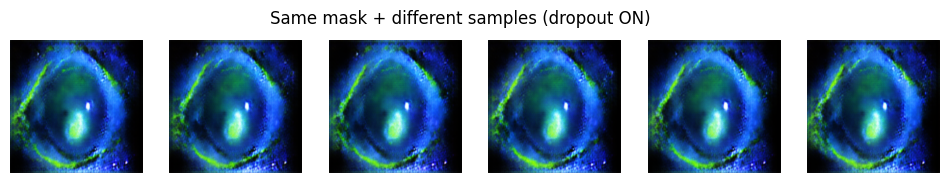

In [20]:
def show_same_mask_variants(mask_index=0, M_show=6):
    u= ulcer_v3[mask_index:mask_index+1]
    c= cornea_v3[mask_index:mask_index+1]

    cond = make_cond(c[0], u[0])[None, ...]
    cond_n = cond*2.0 - 1.0
    plt.figure(figsize=(12,2))
    for j in range(M_show):
        gen = generatorV2(cond_n, training=True).numpy()[0]
        gen = ((gen + 1.0)/2.0).clip(0,1)
        plt.subplot(1, M_show, j+1)
        plt.imshow(gen)
        plt.axis("off")
    plt.suptitle("Same mask + different samples (dropout ON)")
    plt.show()
show_same_mask_variants(mask_index=0, M_show=6)

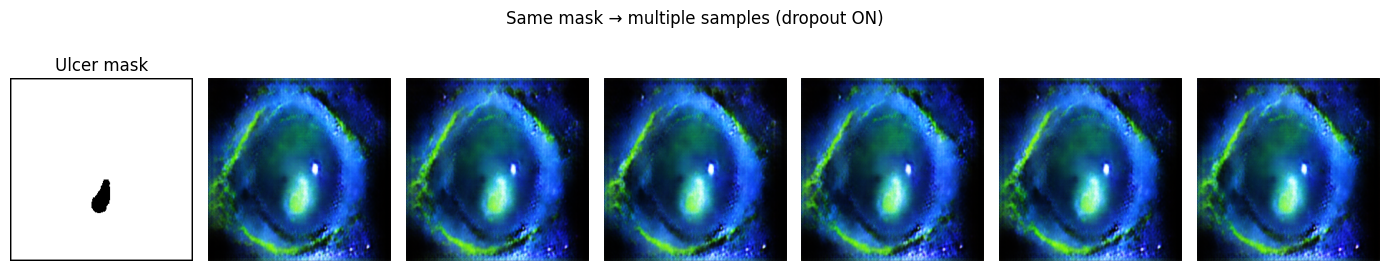

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def show_same_mask_variants(mask_index=0, M_show=6):
    u = ulcer_v3[mask_index]   # (H,W,1)
    c = cornea_v3[mask_index]  # (H,W,1)

    cond = make_cond(c, u)[None, ...]
    cond_n = cond * 2.0 - 1.0

    plt.figure(figsize=(2*(M_show+1), 3))

    # --- show the mask first ---
    plt.subplot(1, M_show+1, 1)
    plt.title("Ulcer mask")
    plt.imshow(u.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    # --- show multiple generated samples ---
    for j in range(M_show):
        gen = generatorV2(cond_n, training=True).numpy()[0]
        gen = ((gen + 1.0) / 2.0).clip(0, 1)

        plt.subplot(1, M_show+1, j+2)
        plt.imshow(gen)
        plt.axis("off")

    plt.suptitle("Same mask → multiple samples (dropout ON)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example
show_same_mask_variants(mask_index=0, M_show=6)


Goal was to : Generate synthetic images that are paired with correct ulcer masks -> this pairing constraint is what forces the problem into the conditional generation category

I could have used somethign else but pix2pix was the most reasonable choice I thought of for my constraints
1.   The synthetic data needed to preserve exact spatial correspondence between the ulcer mask and the generated image. Pix2pix directly enforces this by conditioning on the mask.
2.   Diffusion models could be used for unconditional or weakly conditioned synthesis but enforcing strict pixel-level correspondence with a lesion mask is more complex and computationally expensive.
3.   Unconditional GANs generate realistic images but do not provide paired labels, which limits their usefulness for supervised segmentation tasks.
4.   Multimodal conditional GANs such as BicycleGAN explicitly model multiple outputs per condition. However, they require additional latent encoders and consistency losses, increasing complexity. Given the project scope, pix2pix provided a simpler and more stable baseline.

# Conclusion
The aim of the synthetic data was to improve segmentation robustness rather than maximise visual diversity. For this purpose, mask driven augmentation combined with pix2pix is sufficient.

Although the overall goal was to generate synthetic training data, the data needed to be paired with accurate ulcer masks. This makes the task a conditional image synthesis problem. Pix2pix was chosen because it directly enforces spatial alignment between the mask and the generated image, which is essential for segmentation. While more advanced generative models exist, they either do not guarantee label alignment or require substantially more complexity. Instead of forcing image-level randomness, diversity was introduced through realistic geometric perturbations of the ulcer masks, which directly targets segmentation robustness.

In [24]:
import os, random
import numpy as np
import cv2
import matplotlib.pyplot as plt

def bin01(x):
    x = np.asarray(x).squeeze()
    return (x > 0).astype(np.uint8)

def overlayMask(img_rgb, mask01, alpha=0.45):
    out = img_rgb.copy()
    on = mask01 > 0
    out[on] = (0.55*out[on] + alpha*np.array([255,0,0])).astype(np.uint8)
    return out

def readRgb(path):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

def readGray(path):
    m =cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
      raise FileNotFoundError(path)
    return m

def cannyEdges(mask01):
    e= cv2.Canny((mask01*255).astype(np.uint8), 50, 150)
    return (e > 0).astype(np.uint8)


# Real vs Synthetic comparison grid
Tryign to understand whether the synthetic images look like plausible samples from the same data distribution as the real images and are their masks correctly aligned?

# Conclusion
They do look from the same dataset

In [28]:
def show_real_vs_synth(train_images, train_ulcer, syn_img_dir, syn_msk_dir, n=6, seed=0):
  random.seed(seed)
  real_ids= random.sample(range(len(train_images)), min(n, len(train_images)))
  syn_fns= sorted([f for f in os.listdir(syn_img_dir) if f.endswith(".png")])
  if  not syn_fns:
      print("No synthetic images found in", syn_img_dir)
      return
  syn_ids = random.sample(range(len(syn_fns)), min(n, len(syn_fns)))

  plt.figure(figsize=(12, 3*n))
  for r in range(len(real_ids)):
      i = real_ids[r]
      real_img = (train_images[i] * 255).clip(0,255).astype(np.uint8)  # if your train_images are [0,1]
      real_msk = bin01(train_ulcer[i])
      real_ov  = overlayMask(real_img, real_msk)

      fn = syn_fns[syn_ids[r]]
      syn_img = readRgb(os.path.join(syn_img_dir, fn))
      syn_msk = bin01(readGray(os.path.join(syn_msk_dir, fn)))
      syn_ov  = overlayMask(syn_img, syn_msk)


      plt.subplot(n, 4, r*4 + 1); plt.title("Real"); plt.imshow(real_img); plt.axis("off")
      plt.subplot(n, 4, r*4 + 2); plt.title("Real overlay"); plt.imshow(real_ov); plt.axis("off")
      plt.subplot(n, 4, r*4 + 3); plt.title("Synthetic"); plt.imshow(syn_img); plt.axis("off")
      plt.subplot(n, 4, r*4 + 4); plt.title("Synthetic overlay"); plt.imshow(syn_ov); plt.axis("off")

  plt.tight_layout()
  plt.show()

show_real_vs_synth(train_images, train_ulcer, syn_img_dir, syn_msk_dir, n=6, seed=42)


Output hidden; open in https://colab.research.google.com to view.

# mask perturbation triplet

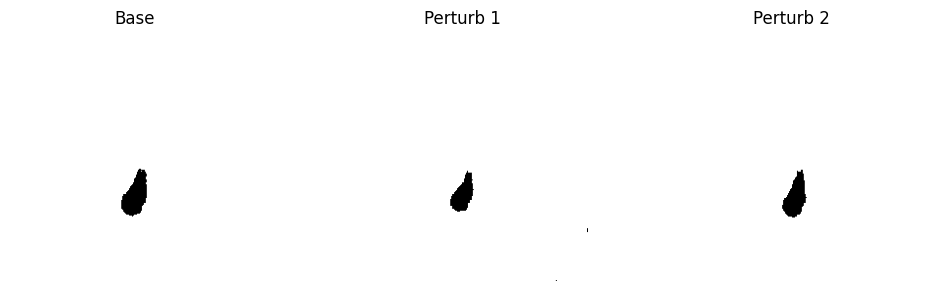

In [29]:
def show_mask_triplet(pert_path, original_index=0, per_original=3):
    pert = np.load(pert_path)
    if pert.ndim == 3: pert = pert[..., None]
    start = original_index * per_original
    m0 = bin01(pert[start + 0])
    m1 = bin01(pert[start + 1])
    m2 = bin01(pert[start + 2])

    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.title("Base"); plt.imshow(m0, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Perturb 1"); plt.imshow(m1, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Perturb 2"); plt.imshow(m2, cmap="gray"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_mask_triplet(os.path.join(BASE, "perturbed_masks.npy"), original_index=0, per_original=3)


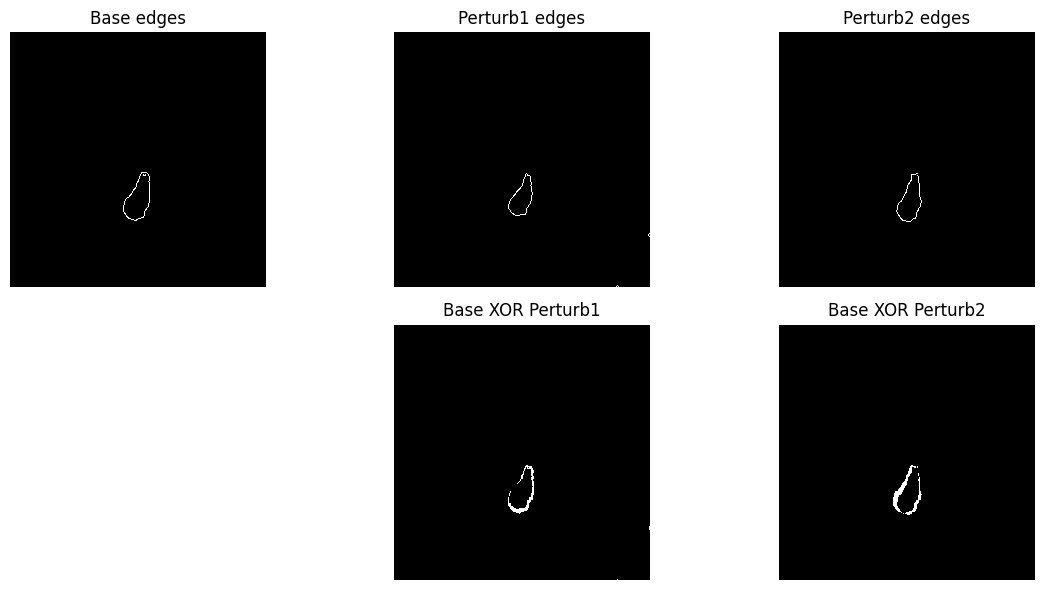

In [30]:
def show_mask_differences(pert_path, original_index=0, per_original=3):
    pert = np.load(pert_path)
    if pert.ndim == 3: pert = pert[..., None]
    start = original_index * per_original
    m0 = bin01(pert[start + 0])
    m1 = bin01(pert[start + 1])
    m2 = bin01(pert[start + 2])

    d01 = (m0 ^ m1).astype(np.uint8)
    d02 = (m0 ^ m2).astype(np.uint8)

    e0 = cannyEdges(m0)
    e1 = cannyEdges(m1)
    e2 = cannyEdges(m2)

    plt.figure(figsize=(12, 6))
    plt.subplot(2,3,1); plt.title("Base edges"); plt.imshow(e0, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,2); plt.title("Perturb1 edges"); plt.imshow(e1, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,3); plt.title("Perturb2 edges"); plt.imshow(e2, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,5); plt.title("Base XOR Perturb1"); plt.imshow(d01, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,6); plt.title("Base XOR Perturb2"); plt.imshow(d02, cmap="gray"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_mask_differences(os.path.join(BASE, "perturbed_masks.npy"), original_index=0, per_original=3)


# This shows the difference between perturbed masks and original ones at pixel level